## Load Data and Libraries

In [9]:
# from google.cloud import bigquery
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, auc, 
                             classification_report, RocCurveDisplay, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, recall_score, precision_score)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df = pd.read_csv("data/cleaned_data.csv", index_col=0)
print("Data Loaded")
print(f"Shape of the data: {df.shape}")

print(f"Columns: {df.columns.tolist()}")
print(f"Data types:\n{df.dtypes}")

Data Loaded
Shape of the data: (34830, 24)
Columns: ['care_unit', 'admission_type', 'admission_location', 'language', 'marital_status', 'race', 'hospital_expire_flag', 'gender', 'age', 'rr_interval', 'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'ecg_bucket', 'temperature', 'spo2', 'glucose', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate']
Data types:
care_unit                object
admission_type           object
admission_location       object
language                 object
marital_status           object
race                     object
hospital_expire_flag      int64
gender                    int64
age                       int64
rr_interval             float64
qrs_onset               float64
qrs_end                 float64
t_end                   float64
qrs_axis                float64
t_axis                  float64
ecg_bucket               object
temperature             float64
spo2                    float64
glucose                 float64
heart_rate              float

## Exploratory Data Analysis

In [10]:
print("Class distribution:")
print(df[df['hospital_expire_flag'] == 1].shape[0], df[df['hospital_expire_flag'] == 0].shape[0])
print(f"\nMortality rate: {df['hospital_expire_flag'].mean():.2%}")

# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

Class distribution:
4195 30635

Mortality rate: 12.04%

Missing values per column:
Series([], dtype: int64)


## Preprocessing

In [11]:
categorical_cols = [
    'care_unit', 'admission_type', 'admission_location',
    'language', 'marital_status', 'race',
    'ecg_bucket'
]

numeric_cols = [
    'age', 'rr_interval', 'qrs_onset', 
    'qrs_end', 't_end','qrs_axis', 
    't_axis', 'temperature', 'spo2', 
    'glucose', 'heart_rate', 'sbp', 
    'dbp', 'mbp', 'resp_rate'
]

# Separate features and target variable
y = df['hospital_expire_flag']
X = df[categorical_cols + numeric_cols]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")
print("Data splitted into training and testing sets\n")
print("Training columns:")
print(X_train.columns)   
print("\nFirst 5 rows of the training labels:")
print(y_train.head())

Training set shape: (27864, 22), (27864,)
Testing set shape: (6966, 22), (6966,)
Data splitted into training and testing sets

Training columns:
Index(['care_unit', 'admission_type', 'admission_location', 'language',
       'marital_status', 'race', 'ecg_bucket', 'age', 'rr_interval',
       'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'temperature',
       'spo2', 'glucose', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate'],
      dtype='object')

First 5 rows of the training labels:
18952    1
11651    0
10459    0
5871     0
26449    0
Name: hospital_expire_flag, dtype: int64


## Modeling

In [12]:
# TODO: One-hot encode categorical variables and standardize numerical features in a pipeline
# Preprocessing for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single column transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Calculate class imbalance ratio for xgboost's scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos
print(f"Class ratio (neg/pos): {ratio:.1f}")

# TODO: Models to compare
# Added xgboost with scale_pos_weight to handle imbalance
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(          
        n_estimators=200,
        scale_pos_weight=ratio,        # handles imbalance
        random_state=42,
        eval_metric='auc',
        verbosity=0                    # suppress warnings
    )
}

# TODO: Train and evaluate all models
models_fitted = {}  

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_scores = cross_val_score(
        pipe, X_train, y_train,
        cv=StratifiedKFold(5), scoring='roc_auc'
    )
    
    if name == 'Gradient Boosting':
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        pipe.fit(X_train, y_train,
                 model__sample_weight=sample_weights)  # ← fix
    else:
        pipe.fit(X_train, y_train)

    # y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)

    models_fitted[name] = pipe

    print(f"{name}:")
    print(f"  CV AUC   = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"  Test AUC = {test_auc:.3f}\n")
    # print(classification_report(y_test, y_pred, 
    #                             target_names=['Survived', 'Died']))
    # print(f"Average Precision Score: {average_precision_score(y_test, y_prob):.3f}")

Class ratio (neg/pos): 7.3
Logistic Regression:
  CV AUC   = 0.802 ± 0.003
  Test AUC = 0.806

Random Forest:
  CV AUC   = 0.817 ± 0.005
  Test AUC = 0.814

Gradient Boosting:
  CV AUC   = 0.823 ± 0.002
  Test AUC = 0.822

XGBoost:
  CV AUC   = 0.783 ± 0.011
  Test AUC = 0.795



## Find the Best Threshold with Highest F1 Score

In [13]:
# Find best threshold for each model
best_thresholds = {}

for name, pipe in models_fitted.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.05, 0.60, 0.05):
        y_pred_t = (y_prob >= thresh).astype(int)
        f1 = f1_score(y_test, y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = round(thresh, 2)
    
    best_thresholds[name] = best_thresh
    print(f"{name}: best threshold = {best_thresh}, F1 = {best_f1:.3f}")

print("\nBest thresholds:", best_thresholds)

Logistic Regression: best threshold = 0.55, F1 = 0.403
Random Forest: best threshold = 0.2, F1 = 0.421
Gradient Boosting: best threshold = 0.55, F1 = 0.428
XGBoost: best threshold = 0.45, F1 = 0.405

Best thresholds: {'Logistic Regression': np.float64(0.55), 'Random Forest': np.float64(0.2), 'Gradient Boosting': np.float64(0.55), 'XGBoost': np.float64(0.45)}


## Model Evaluation

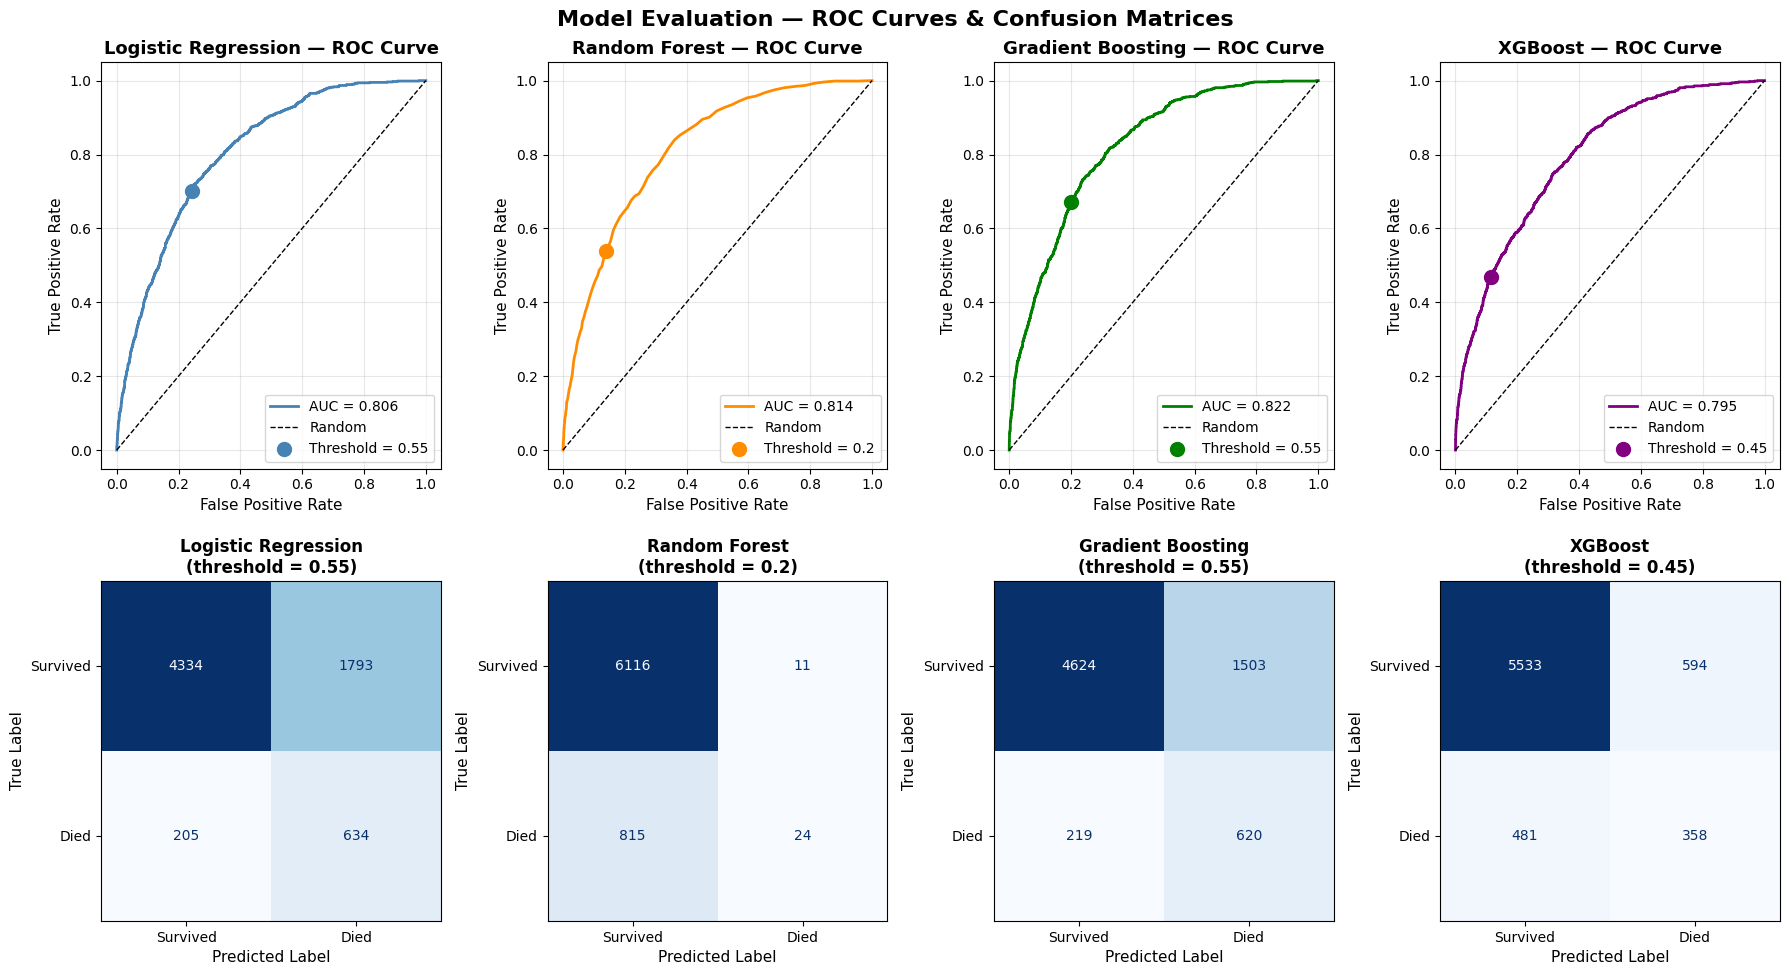

In [14]:
# ROC Curves and Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

colors = ['steelblue', 'darkorange', 'green', 'purple']

for i, ((name, pipe), color) in enumerate(zip(models_fitted.items(), colors)):

    y_prob = pipe.predict_proba(X_test)[:, 1]
    thresh = best_thresholds[name]          # use best threshold
    y_pred = (y_prob >= thresh).astype(int) # apply threshold

    # ── Top Row: ROC Curves ──
    ax_roc = axes[0, i]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"AUC = {roc_auc:.3f}")
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

    # Mark the point at best threshold
    best_idx = np.argmin(np.abs(
        y_prob[np.argsort(y_prob)] - thresh
    ))
    fpr_thresh = 1 - recall_score(y_test, y_pred, pos_label=0)
    tpr_thresh = recall_score(y_test, y_pred, pos_label=1)
    ax_roc.scatter(fpr_thresh, tpr_thresh, 
                   color=color, s=100, zorder=5,
                   label=f"Threshold = {thresh}")  # shows threshold point

    ax_roc.set_xlabel('False Positive Rate', fontsize=11)
    ax_roc.set_ylabel('True Positive Rate', fontsize=11)
    ax_roc.set_title(f'{name} — ROC Curve', fontsize=13, fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=10)
    ax_roc.grid(alpha=0.3)

    # ── Bottom Row: Confusion Matrices ──
    ax_cm = axes[1, i]
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Survived', 'Died']
    )
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f'{name}\n(threshold = {thresh})',  # shows threshold used
                     fontsize=12, fontweight='bold')
    ax_cm.set_xlabel('Predicted Label', fontsize=11)
    ax_cm.set_ylabel('True Label', fontsize=11)

plt.suptitle('Model Evaluation — ROC Curves & Confusion Matrices',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sanity_outputs/model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance

Total features after encoding: 98
['age', 'rr_interval', 'qrs_onset', 'qrs_end', 't_end', 'qrs_axis', 't_axis', 'temperature', 'spo2', 'glucose', 'heart_rate', 'sbp', 'dbp', 'mbp', 'resp_rate', 'care_unit_ccu', 'care_unit_cvicu', 'care_unit_micu', 'care_unit_micu_sicu', 'care_unit_neuro', 'care_unit_other', 'care_unit_sicu', 'care_unit_tsicu', 'admission_type_ambulatory_observation', 'admission_type_direct_emer', 'admission_type_direct_observation', 'admission_type_elective', 'admission_type_eu_observation', 'admission_type_ew_emer', 'admission_type_observation_admit', 'admission_type_surgical_same_day_admission', 'admission_type_urgent', 'admission_location_ambulatory_surgery_transfer', 'admission_location_clinic_referral', 'admission_location_emergency_room', 'admission_location_information_not_available', 'admission_location_internal_transfer_to_or_from_psych', 'admission_location_pacu', 'admission_location_physician_referral', 'admission_location_procedure_site', 'admission_locatio

,feature,importance
0,resp_rate,0.155871
1,care_unit_cvicu,0.151547
2,sbp,0.110632
3,age,0.079422
4,temperature,0.072884
5,rr_interval,0.054171
6,spo2,0.052821
7,glucose,0.039725
8,dbp,0.036402
9,heart_rate,0.029314


<Figure size 1000x600 with 0 Axes>

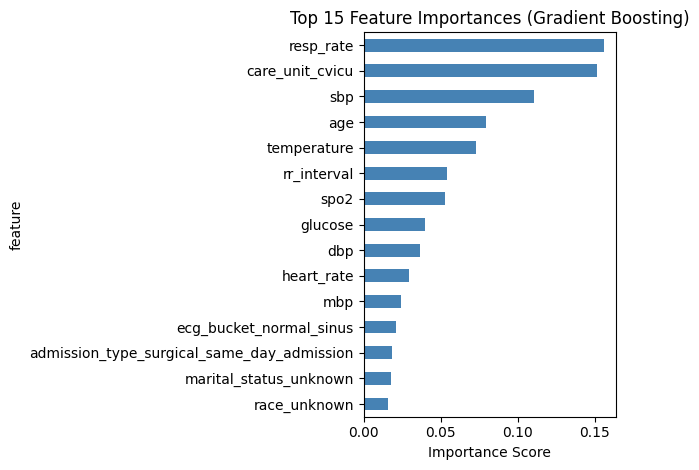

In [15]:
# Feature Importance Analysis for Gradient Boosting
# Get feature names after one-hot encoding
cat_feature_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
    .tolist()
)

all_feature_names = numeric_cols + cat_feature_names
print(f"Total features after encoding: {len(all_feature_names)}")
print(all_feature_names)

# Use the already fitted Gradient Boosting pipeline
gb_pipe = models_fitted['Gradient Boosting']  # from previous step
gb_model = gb_pipe.named_steps['model']

# Build importance dataframe
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(importance_df.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))
importance_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    legend=False, color='steelblue'
)
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('sanity_outputs/feature_importance.png', dpi=150)
plt.show()

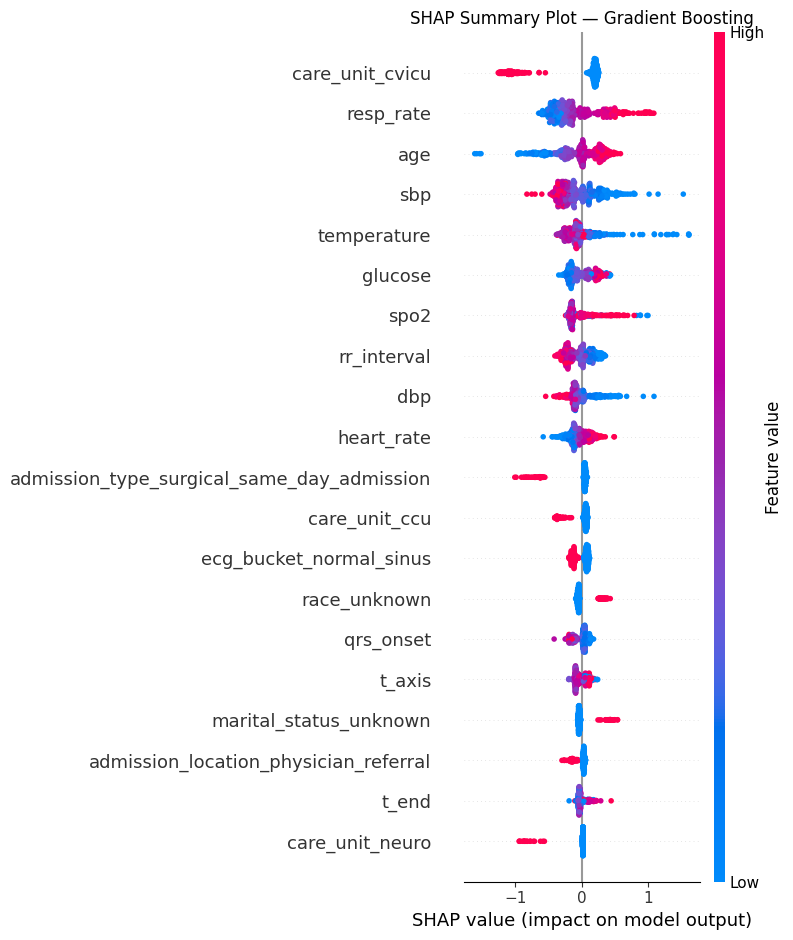

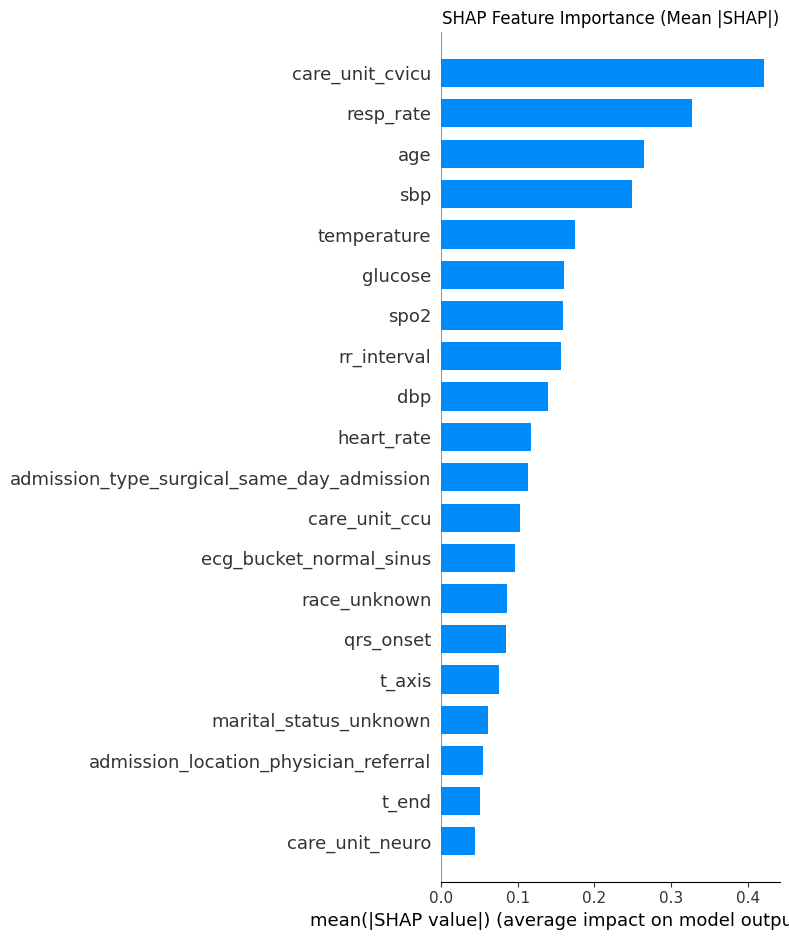

In [16]:
# WARNING: Take a while to run SHAP on the full test set, so we are using a subset for faster results.
# Using Gradient Boosting as an example for SHAP analysis
import shap

# Transform test data using fitted preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Use a subset of the test data for SHAP to speed up computation
sample_size = 500
X_shap = X_test_transformed[:sample_size]

# ── Gradient Boosting SHAP ──
gb_model = models_fitted['Gradient Boosting'].named_steps['model']
explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_shap)

# For binary classification, shap_values[1] = positive class (died)
shap_vals = shap_values_gb[1] if isinstance(shap_values_gb, list) else shap_values_gb

# Summary plot — shows most impactful features
plt.figure()
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=all_feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Gradient Boosting')
plt.tight_layout()
plt.savefig('sanity_outputs/shap_summary.png', dpi=300)
plt.show()

# Bar plot — mean absolute SHAP values
plt.figure()
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=all_feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.savefig('sanity_outputs/shap_bar.png', dpi=300)
plt.show()